In [ ]:
!pip install risk-parity-constrained

# Risk Parity Portfolio Optimization Demo

This notebook is the main demonstration for the `riskparity` package. It walks from a minimal example to diagnostic plots, constrained optimization, a weight-cap sweep, and a randomized robustness check.

The goal is to make the package easy to inspect: every solver output is checked for feasibility, portfolio risk, and relative risk contributions.

## Method overview

Risk parity allocates capital so that each asset contributes roughly the same share of total portfolio variance. For weights `w` and covariance matrix `Sigma`, asset `i` contributes

`RC_i = w_i (Sigma w)_i`.

The package exposes two solvers:

- `CCDSolver`: unconstrained long-only risk parity baseline.
- `SCASolver`: constrained solver with a per-asset upper bound `w_i <= w_max`.

When the upper bound is tight, exact equal risk contribution may no longer be feasible. The constrained example below shows this trade-off explicitly.

## Setup

Run this notebook from the repository root or from the `notebooks/` folder. For a packaged release, the local path setup can be replaced by a normal `%pip install risk-parity-constrained` cell.

In [ ]:
# Local development setup.
# For a published package, use instead:
# %pip install risk-parity-constrained --quiet

import sys
from pathlib import Path

repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt

from riskparity import (
    CCDSolver,
    SCASolver,
    relative_risk_contributions,
    risk_contribution_gap,
    risk_contributions,
)

np.set_printoptions(precision=4, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")

print("Imports OK")
print("Repository root:", repo_root)

Imports OK
Repository root: /Users/fangyujun/Desktop/math5030/MATH5030_group_project


## Helper functions

The helper functions below keep the notebook focused on interpretation. They compute portfolio variance, feasibility checks, and a compact comparison table for several solver outputs.

In [ ]:
def portfolio_variance(Sigma, w):
    return float(w @ Sigma @ w)


def portfolio_volatility(Sigma, w):
    return float(np.sqrt(portfolio_variance(Sigma, w)))


def max_rrc_deviation(Sigma, w):
    rrc = relative_risk_contributions(Sigma, w)
    return float(np.max(np.abs(rrc - 1.0 / len(w))))


def diagnostics(Sigma, weights_by_name, w_max=None):
    rows = []
    for name, w in weights_by_name.items():
        row = {
            "solver": name,
            "sum(w)": w.sum(),
            "min(w)": w.min(),
            "max(w)": w.max(),
            "volatility": portfolio_volatility(Sigma, w),
            "max RRC dev": max_rrc_deviation(Sigma, w),
            "RC gap": risk_contribution_gap(Sigma, w),
        }
        if w_max is not None:
            row["cap feasible"] = bool(np.all(w <= w_max + 1e-10))
        rows.append(row)
    return rows


def print_diagnostics(rows):
    headers = list(rows[0])
    widths = {
        h: max(len(h), *(len(f"{row[h]:.6g}") if isinstance(row[h], float) else len(str(row[h])) for row in rows))
        for h in headers
    }
    print(" | ".join(h.ljust(widths[h]) for h in headers))
    print("-+-".join("-" * widths[h] for h in headers))
    for row in rows:
        values = []
        for h in headers:
            value = row[h]
            values.append((f"{value:.6g}" if isinstance(value, float) else str(value)).ljust(widths[h]))
        print(" | ".join(values))

## Minimal runnable example

The two-asset case is a quick smoke test: weights should sum to one, stay non-negative, and produce interpretable risk contributions.

In [ ]:
Sigma_small = np.array(
    [
        [0.04, 0.01],
        [0.01, 0.09],
    ]
)

w_small = CCDSolver(Sigma_small).solve()
rrc_small = relative_risk_contributions(Sigma_small, w_small)

print("CCD weights:", w_small)
print("Sum of weights:", w_small.sum())
print("Relative risk contributions:", rrc_small)
print("Portfolio volatility:", portfolio_volatility(Sigma_small, w_small))

CCD weights: [0.6 0.4]
Sum of weights: 1.0
Relative risk contributions: [0.5 0.5]
Portfolio volatility: 0.18330302779822488


## Closed-form diagonal check

For a diagonal covariance matrix, the risk parity solution is proportional to inverse volatility. This gives a useful correctness check that does not depend on plotting or visual inspection.

In [ ]:
variances = np.array([0.04, 0.09, 0.16, 0.25])
Sigma_diag = np.diag(variances)

w_diag = CCDSolver(Sigma_diag, tol=1e-10, max_iter=2000).solve()
inv_vol = 1.0 / np.sqrt(variances)
w_closed_form = inv_vol / inv_vol.sum()

print("CCD diagonal solution: ", w_diag)
print("Closed-form solution:", w_closed_form)
print("Max absolute error:", np.max(np.abs(w_diag - w_closed_form)))
print("Relative risk contributions:", relative_risk_contributions(Sigma_diag, w_diag))

CCD diagonal solution:  [0.3896 0.2597 0.1948 0.1558]
Closed-form solution: [0.3896 0.2597 0.1948 0.1558]
Max absolute error: 0.0
Relative risk contributions: [0.25 0.25 0.25 0.25]


### Interpretation: diagonal correctness check

The CCD solution matches the closed-form inverse-volatility weights exactly in this diagonal case, and each asset contributes 25% of total risk. This is a useful correctness benchmark because the expected answer is known analytically before running the solver.

## Five-asset covariance example

The next cells use a small but realistic covariance matrix built from volatilities and correlations. This keeps the example transparent while still showing nontrivial diversification effects.

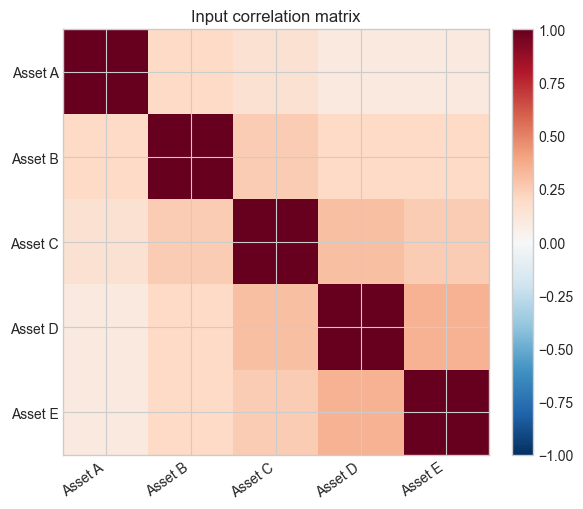

In [ ]:
asset_names = np.array(["Asset A", "Asset B", "Asset C", "Asset D", "Asset E"])

vol = np.array([0.10, 0.20, 0.28, 0.36, 0.48])
corr = np.array(
    [
        [1.00, 0.20, 0.15, 0.10, 0.10],
        [0.20, 1.00, 0.25, 0.20, 0.20],
        [0.15, 0.25, 1.00, 0.30, 0.25],
        [0.10, 0.20, 0.30, 1.00, 0.35],
        [0.10, 0.20, 0.25, 0.35, 1.00],
    ]
)
Sigma = np.outer(vol, vol) * corr

fig, ax = plt.subplots(figsize=(6.5, 5.2))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(asset_names)))
ax.set_yticks(np.arange(len(asset_names)))
ax.set_xticklabels(asset_names, rotation=35, ha="right")
ax.set_yticklabels(asset_names)
ax.set_title("Input correlation matrix")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Unconstrained vs constrained portfolio

Here `CCDSolver` gives the unconstrained baseline. `SCASolver` imposes a maximum 25% allocation to any single asset. The diagnostics table reports feasibility and how close the risk contributions are to equal shares.

In [ ]:
w_max = 0.25

ccd_solver = CCDSolver(Sigma, tol=1e-10, max_iter=2000)
sca_solver = SCASolver(Sigma, w_max=w_max, tol=1e-7, max_iter=3000)

w_ccd = ccd_solver.solve()
w_sca = sca_solver.solve()

rrc_ccd = relative_risk_contributions(Sigma, w_ccd)
rrc_sca = relative_risk_contributions(Sigma, w_sca)

print("CCD converged:", ccd_solver.converged_, "iterations:", ccd_solver.n_iter_)
print("SCA converged:", sca_solver.converged_, "iterations:", sca_solver.n_iter_)
print()
print_diagnostics(diagnostics(Sigma, {"CCD unconstrained": w_ccd, "SCA constrained": w_sca}, w_max=w_max))

CCD converged: True iterations: 10
SCA converged: True iterations: 1274

solver            | sum(w) | min(w)    | max(w)  | volatility | max RRC dev | RC gap      | cap feasible
------------------+--------+-----------+---------+------------+-------------+-------------+-------------
CCD unconstrained | 1      | 0.0843596 | 0.45877 | 0.124932   | 4.79311e-13 | 7.48099e-15 | False       
SCA constrained   | 1      | 0.119446  | 0.25    | 0.158615   | 0.144602    | 0.00363802  | True        


### Interpretation: constrained vs unconstrained diagnostics

The unconstrained CCD portfolio reaches almost perfect equal risk contribution, but it concentrates heavily in the lowest-volatility asset: its largest weight is about `0.459`. The SCA portfolio satisfies the 25% cap, so it must redistribute capital into the other assets. The cost is a visible increase in risk-contribution imbalance, which is exactly the constrained trade-off we want the demo to show.

## Portfolio weights

The red line is the SCA upper bound. A constrained solution is useful when the unconstrained optimum concentrates too much capital in one asset.

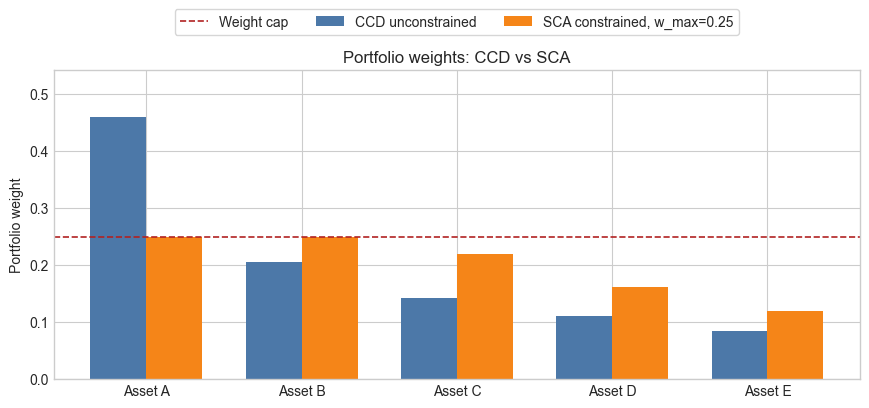

In [ ]:
x = np.arange(len(asset_names))
width = 0.36

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.bar(x - width / 2, w_ccd, width, label="CCD unconstrained", color="#4C78A8")
ax.bar(x + width / 2, w_sca, width, label=f"SCA constrained, w_max={w_max}", color="#F58518")
ax.axhline(w_max, color="#B22222", linestyle="--", linewidth=1.2, label="Weight cap")
ax.set_xticks(x)
ax.set_xticklabels(asset_names)
ax.set_ylabel("Portfolio weight")
ax.set_title("Portfolio weights: CCD vs SCA")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=3, frameon=True)
ax.set_ylim(0, max(w_ccd.max(), w_sca.max(), w_max) * 1.18)
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

## Relative risk contributions

Risk parity targets equal relative risk contributions. The constrained solver may deviate more when the cap binds, but the plot should still show a balanced allocation relative to naive capital weights.

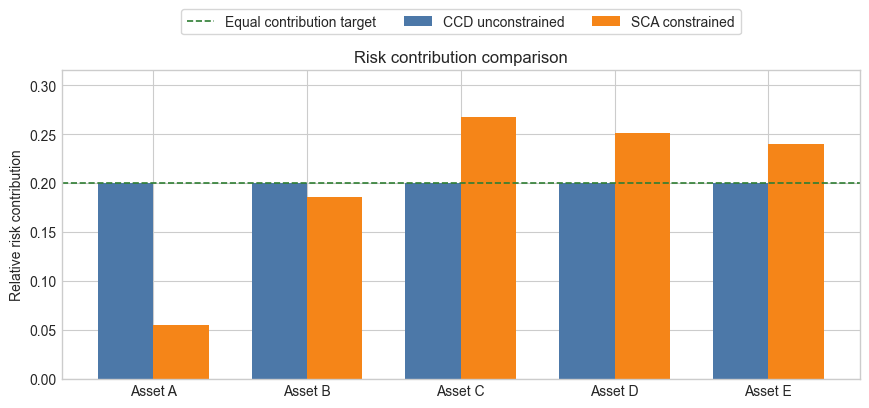

CCD relative risk contributions: [0.2 0.2 0.2 0.2 0.2]
SCA relative risk contributions: [0.0554 0.1857 0.2673 0.2512 0.2404]
Equal contribution target: 0.2


In [ ]:
target_rrc = 1.0 / len(asset_names)

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.bar(x - width / 2, rrc_ccd, width, label="CCD unconstrained", color="#4C78A8")
ax.bar(x + width / 2, rrc_sca, width, label="SCA constrained", color="#F58518")
ax.axhline(target_rrc, color="#2E7D32", linestyle="--", linewidth=1.2, label="Equal contribution target")
ax.set_xticks(x)
ax.set_xticklabels(asset_names)
ax.set_ylabel("Relative risk contribution")
ax.set_title("Risk contribution comparison")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.22), ncol=3, frameon=True)
ax.set_ylim(0, max(rrc_ccd.max(), rrc_sca.max(), target_rrc) * 1.18)
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

print("CCD relative risk contributions:", rrc_ccd)
print("SCA relative risk contributions:", rrc_sca)
print("Equal contribution target:", target_rrc)

### Interpretation: risk contribution comparison

The CCD bars are essentially flat at the equal contribution target, confirming that the unconstrained solver achieves risk parity for this covariance matrix. The SCA bars are visibly uneven because the 25% upper bound is strongly active: the low-volatility asset cannot receive enough capital to keep its risk contribution near 20%, so the remaining assets contribute more risk. This illustrates the main trade-off of the constrained problem: feasibility under allocation limits can prevent exact equal risk contribution.

## Weight-cap sensitivity sweep

This section turns the constrained solver into a small numerical experiment. As `w_max` decreases, the feasible region shrinks. We track portfolio volatility, the largest weight, and risk-contribution imbalance.

In [ ]:
cap_grid = np.array([1.00, 0.45, 0.35, 0.30, 0.25, 0.22, 0.20])
sweep = []

for cap in cap_grid:
    solver = SCASolver(Sigma, w_max=cap, tol=1e-7, max_iter=3000)
    w = solver.solve()
    sweep.append(
        {
            "w_max": cap,
            "max_weight": w.max(),
            "volatility": portfolio_volatility(Sigma, w),
            "max_rrc_dev": max_rrc_deviation(Sigma, w),
            "iterations": solver.n_iter_,
            "converged": solver.converged_,
        }
    )

print_diagnostics(sweep)

w_max | max_weight | volatility | max_rrc_dev | iterations | converged
------+------------+------------+-------------+------------+----------
1     | 0.45877    | 0.124932   | 5.49816e-12 | 1          | True     
0.45  | 0.45       | 0.126018   | 0.00866059  | 830        | True     
0.35  | 0.35       | 0.138876   | 0.088211    | 2488       | True     
0.3   | 0.3        | 0.145926   | 0.117387    | 2553       | True     
0.25  | 0.25       | 0.158615   | 0.144602    | 1274       | True     
0.22  | 0.22       | 0.171212   | 0.159477    | 625        | True     
0.2   | 0.2        | 0.186058   | 0.202662    | 1          | True     


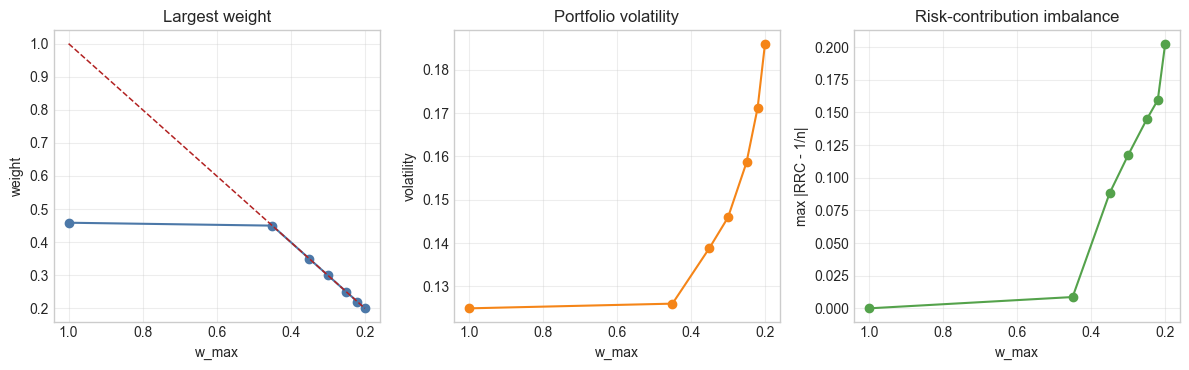

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))

axes[0].plot(cap_grid, [row["max_weight"] for row in sweep], marker="o", color="#4C78A8")
axes[0].plot(cap_grid, cap_grid, linestyle="--", color="#B22222", linewidth=1.1)
axes[0].set_title("Largest weight")
axes[0].set_xlabel("w_max")
axes[0].set_ylabel("weight")

axes[1].plot(cap_grid, [row["volatility"] for row in sweep], marker="o", color="#F58518")
axes[1].set_title("Portfolio volatility")
axes[1].set_xlabel("w_max")
axes[1].set_ylabel("volatility")

axes[2].plot(cap_grid, [row["max_rrc_dev"] for row in sweep], marker="o", color="#54A24B")
axes[2].set_title("Risk-contribution imbalance")
axes[2].set_xlabel("w_max")
axes[2].set_ylabel("max |RRC - 1/n|")

for ax in axes:
    ax.invert_xaxis()
    ax.grid(True, alpha=0.35)

plt.tight_layout()
plt.show()

### Interpretation: weight-cap sensitivity

For `w_max = 1.00`, the constrained solver reproduces the unconstrained risk parity solution. Once the cap moves below the unconstrained largest weight of about `0.459`, the cap becomes binding and the solution changes sharply. Tighter caps force more capital into higher-volatility assets, so portfolio volatility and risk-contribution imbalance both increase. The jump near `w_max = 0.20` is expected because, with five assets, `0.20` forces the equal-weight portfolio.

## Randomized robustness check

A demo notebook should not replace the test suite, but a small randomized check is helpful for presentation. The function below generates positive definite covariance matrices with random volatilities and correlations, then confirms that both solvers return feasible portfolios.

In [ ]:
def random_covariance(rng, n):
    factors = rng.normal(size=(n, min(4, n)))
    factor_cov = factors @ factors.T
    jitter = np.diag(0.2 + rng.random(n))
    raw = factor_cov + jitter
    std = np.sqrt(np.diag(raw))
    corr = raw / np.outer(std, std)
    vol = rng.uniform(0.10, 0.35, size=n)
    return np.outer(vol, vol) * corr


rng = np.random.default_rng(5030)
robustness_rows = []

for n in [5, 10, 20, 40]:
    gaps_ccd = []
    gaps_sca = []
    feasible_sca = []
    for _ in range(5):
        Sigma_random = random_covariance(rng, n)
        w_ccd_random = CCDSolver(Sigma_random, tol=1e-8, max_iter=3000).solve()
        w_sca_random = SCASolver(Sigma_random, w_max=max(0.15, 1.5 / n), tol=1e-7, max_iter=800).solve()
        gaps_ccd.append(max_rrc_deviation(Sigma_random, w_ccd_random))
        gaps_sca.append(max_rrc_deviation(Sigma_random, w_sca_random))
        feasible_sca.append(np.isclose(w_sca_random.sum(), 1.0) and np.all(w_sca_random >= -1e-10))
    robustness_rows.append(
        {
            "n": n,
            "CCD avg max RRC dev": float(np.mean(gaps_ccd)),
            "SCA avg max RRC dev": float(np.mean(gaps_sca)),
            "SCA feasible runs": f"{sum(feasible_sca)}/{len(feasible_sca)}",
        }
    )

print_diagnostics(robustness_rows)

n  | CCD avg max RRC dev | SCA avg max RRC dev | SCA feasible runs
---+---------------------+---------------------+------------------
5  | 1.71214e-10         | 0.136786            | 5/5              
10 | 6.91488e-10         | 0.147738            | 5/5              
20 | 1.82682e-09         | 0.0197368           | 5/5              
40 | 1.74759e-09         | 1.74767e-09         | 5/5              


### Interpretation: randomized robustness check

Across random covariance matrices with 5, 10, 20, and 40 assets, the CCD solver keeps average RRC deviation near numerical precision. The SCA solver returns feasible portfolios in every run. Its RRC deviation is larger in smaller portfolios when the cap is more restrictive, which is consistent with the constrained formulation rather than a solver failure.

## Infeasible constraint example

The SCA solver validates the weight cap before iterating. For `n` assets, a necessary feasibility condition is `w_max >= 1/n`; otherwise the weights cannot sum to one.

In [ ]:
try:
    SCASolver(Sigma, w_max=0.10).solve()
except ValueError as exc:
    print("Expected infeasibility error:")
    print(exc)

Expected infeasibility error:
w_max=0.1 is infeasible for n=5: need w_max >= 1/n.


### Interpretation: infeasible constraint validation

The infeasible example confirms that the solver catches impossible constraints before optimization starts. With five assets, the weights can sum to one only if `w_max >= 0.20`; therefore `w_max = 0.10` correctly raises a `ValueError`.

## Test suite connection

This notebook shows representative validation examples, while the full automated coverage is in `tests/test_riskparity.py`.

- Correctness and validation tests cover covariance input checks, CCD behavior, diagonal closed-form cases, two-asset sanity checks, valid long-only weights, and equal risk contributions.
- Robustness tests cover constrained solver feasibility, infeasible `w_max`, randomized covariance matrices, cross-dimensional stability, and boundary parameter cases.

## Summary

This notebook demonstrates the full user-facing workflow:

- construct a covariance matrix;
- solve unconstrained and constrained risk parity portfolios;
- verify feasibility and risk-contribution balance;
- visualize weights and risk contributions;
- study how the constraint level changes the solution;
- run a small randomized robustness check.

The main practical takeaway is that CCD gives a clean equal-risk baseline, while SCA makes the allocation usable when portfolio policy requires upper bounds on individual weights.